In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df1 = pd.read_excel("Medibuddy Insurance Data Price.xlsx")
df1

,Policy no.,age,sex,bmi,charges in INR
0,PLC156898,19,female,27.900,16884.92400
1,PLC156907,18,male,33.770,1725.55230
2,PLC156916,28,male,33.000,4449.46200
3,PLC156925,33,male,22.705,21984.47061
4,PLC156934,32,male,28.880,3866.85520
...,...,...,...,...,...
1333,PLC168895,50,male,30.970,10600.54830
1334,PLC168904,18,female,31.920,2205.98080
1335,PLC168913,18,female,36.850,1629.83350
1336,PLC168922,21,female,25.800,2007.94500


In [3]:
df2=pd.read_excel("Medibuddy insurance data personal details.xlsx")
df2

,Policy no.,children,smoker,region
0,PLC157006,0,no,southwest
1,PLC157033,1,no,southwest
2,PLC157060,0,no,southwest
3,PLC157087,1,no,southwest
4,PLC157186,5,no,southwest
...,...,...,...,...
1333,PLC168400,1,yes,northeast
1334,PLC168436,0,yes,northeast
1335,PLC168634,2,yes,northeast
1336,PLC168652,0,yes,northeast


In [4]:
# Merge both the sheets to form a new sheet df 
df = pd.merge(df1,df2, on= 'Policy no.')
df

,Policy no.,age,sex,bmi,charges in INR,children,smoker,region
0,PLC156898,19,female,27.900,16884.92400,0,yes,southwest
1,PLC156907,18,male,33.770,1725.55230,1,no,southeast
2,PLC156916,28,male,33.000,4449.46200,3,no,southeast
3,PLC156925,33,male,22.705,21984.47061,0,no,northwest
4,PLC156934,32,male,28.880,3866.85520,0,no,northwest
...,...,...,...,...,...,...,...,...
1333,PLC168895,50,male,30.970,10600.54830,3,no,northwest
1334,PLC168904,18,female,31.920,2205.98080,0,no,northeast
1335,PLC168913,18,female,36.850,1629.83350,0,no,southeast
1336,PLC168922,21,female,25.800,2007.94500,0,no,southwest


In [5]:
#Save the Merged dataset as Medibuddy Insurance Data Record
df.to_csv('Medibuddy Insurance Data Record.csv',index=False)
print("File created successfully")

File created successfully


In [6]:
df = pd.read_csv('Medibuddy Insurance Data Record.csv')
df

,Policy no.,age,sex,bmi,charges in INR,children,smoker,region
0,PLC156898,19,female,27.900,16884.92400,0,yes,southwest
1,PLC156907,18,male,33.770,1725.55230,1,no,southeast
2,PLC156916,28,male,33.000,4449.46200,3,no,southeast
3,PLC156925,33,male,22.705,21984.47061,0,no,northwest
4,PLC156934,32,male,28.880,3866.85520,0,no,northwest
...,...,...,...,...,...,...,...,...
1333,PLC168895,50,male,30.970,10600.54830,3,no,northwest
1334,PLC168904,18,female,31.920,2205.98080,0,no,northeast
1335,PLC168913,18,female,36.850,1629.83350,0,no,southeast
1336,PLC168922,21,female,25.800,2007.94500,0,no,southwest


In [7]:
# Summary of dataset
df.describe()

,age,bmi,charges in INR,children
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,13270.422265,1.094918
std,14.049960,6.098187,12110.011237,1.205493
min,18.000000,15.960000,1121.873900,0.000000
25%,27.000000,26.296250,4740.287150,0.000000
50%,39.000000,30.400000,9382.033000,1.000000
75%,51.000000,34.693750,16639.912515,2.000000
max,64.000000,53.130000,63770.428010,5.000000


In [8]:
# Check for null values
df.isnull().sum()

Policy no.        0
age               0
sex               0
bmi               0
charges in INR    0
children          0
smoker            0
region            0
dtype: int64

In [9]:
df.columns

Index(['Policy no.', 'age', 'sex', 'bmi', 'charges in INR', 'children',
       'smoker', 'region'],
      dtype='object')

Q1. Does the gender of the person matter for the company as a constraint for extending policies?

In [10]:
# Find the count of target variable i.e Sex / Gender
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [11]:
#Print proportions of each category
df['sex'].value_counts(normalize=True)

sex
male      0.505232
female    0.494768
Name: proportion, dtype: float64

<Axes: xlabel='sex'>

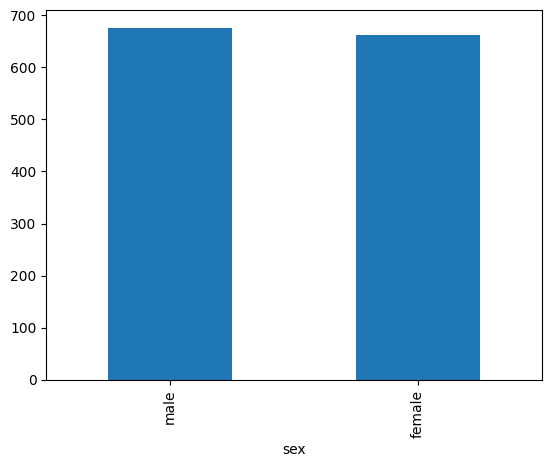

In [12]:
#Bar graph of Target variable
df['sex'].value_counts().plot.bar()

In [13]:
# Define function to categorize Age range
def age_categorize(age):
    if age < 20:
        return "Under 20"
    elif 20 >= age <= 30:
        return "20 - 30"
    elif 30 >= age <= 40:
        return "30 - 40"
    elif 40 >= age <= 50:
        return "40 - 50"
    elif 50 >= age <= 60:
        return "50 - 60"
    else :
        return "60+" 

In [14]:
df['Age_Range'] =  df['age'].apply(age_categorize)
df.head()

,Policy no.,age,sex,bmi,charges in INR,children,smoker,region,Age_Range
0,PLC156898,19,female,27.900,16884.92400,0,yes,southwest,Under 20
1,PLC156907,18,male,33.770,1725.55230,1,no,southeast,Under 20
2,PLC156916,28,male,33.000,4449.46200,3,no,southeast,30 - 40
3,PLC156925,33,male,22.705,21984.47061,0,no,northwest,40 - 50
4,PLC156934,32,male,28.880,3866.85520,0,no,northwest,40 - 50


In [15]:
group_data=df.groupby(['Age_Range','sex']).size()

In [16]:
group_data

Age_Range  sex   
20 - 30    female     14
           male       15
30 - 40    female    134
           male      144
40 - 50    female    127
           male      130
50 - 60    female    140
           male      141
60+        female    181
           male      175
Under 20   female     66
           male       71
dtype: int64

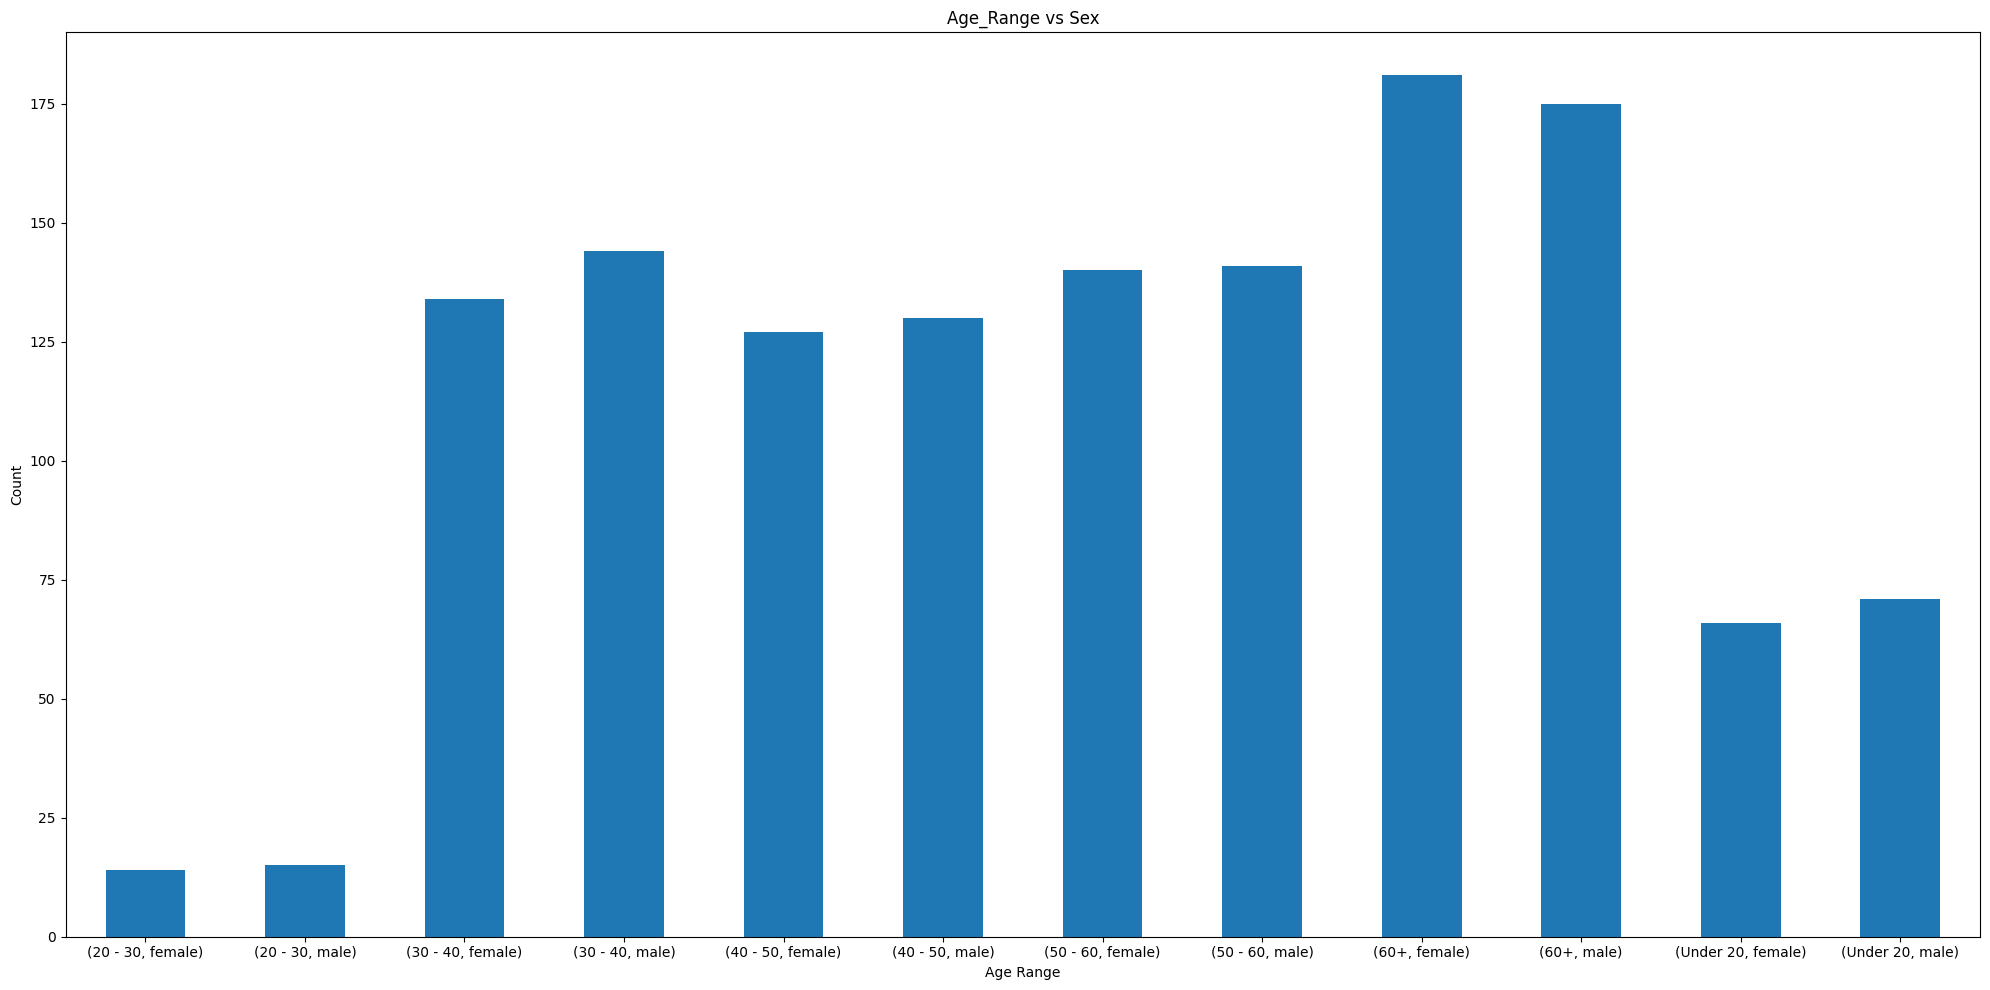

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

group_data.plot(kind='bar', figsize=(20, 10))
plt.title('Age_Range vs Sex')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

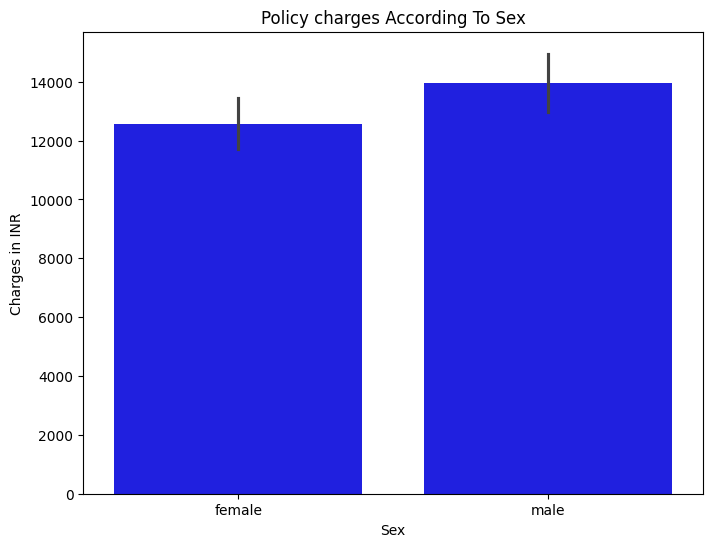

In [18]:
plt.figure(figsize=(8,6))
sns.barplot(x=df['sex'],y=df['charges in INR'],color='blue')
plt.title('Policy charges According To Sex')
plt.xlabel('Sex')
plt.ylabel('Charges in INR')
plt.show()

Ans1. According to my Analysis, Gender of the person matter for the company as a constraint for extending policies because as seen from the above bar plot of age_graph vs sex, for the age range<=60 the policies created in terms of gender i.e; male and female have less variation in them so there is no problem in extending policies but for the age range>60 policies mostly created are for females as compared to males as females pay generally lower life insurance premiums than males due to their longer life expectancy.

Q2. What is the average amount of money the company spent over each policy cover?

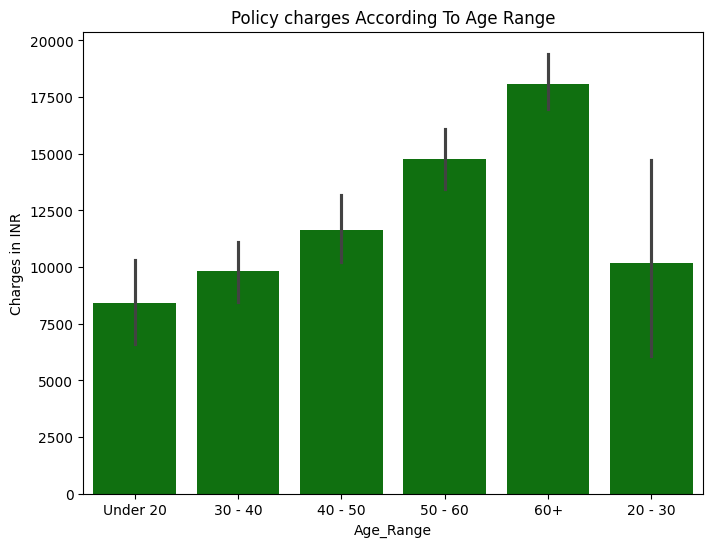

In [19]:
plt.figure(figsize=(8,6))
sns.barplot(x=df['Age_Range'],y=df['charges in INR'],color='green')
plt.title('Policy charges According To Age Range')
plt.xlabel('Age_Range')
plt.ylabel('Charges in INR')
plt.show()

In [20]:
df['Avg_Amt'] =  df['charges in INR'].mean()
df['Avg_Amt']

0       13270.422265
1       13270.422265
2       13270.422265
3       13270.422265
4       13270.422265
            ...     
1333    13270.422265
1334    13270.422265
1335    13270.422265
1336    13270.422265
1337    13270.422265
Name: Avg_Amt, Length: 1338, dtype: float64

Ans2. The average amount of money the company spent over each policy cover is INR 13270 approx.

Q3. Could you advice if the company needs to offer separate policies based upon the geographic location of the person?

In [21]:
# Find the count of target variable i.e Geographic Locations
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [22]:
df.head()

,Policy no.,age,sex,bmi,charges in INR,children,smoker,region,Age_Range,Avg_Amt
0,PLC156898,19,female,27.900,16884.92400,0,yes,southwest,Under 20,13270.422265
1,PLC156907,18,male,33.770,1725.55230,1,no,southeast,Under 20,13270.422265
2,PLC156916,28,male,33.000,4449.46200,3,no,southeast,30 - 40,13270.422265
3,PLC156925,33,male,22.705,21984.47061,0,no,northwest,40 - 50,13270.422265
4,PLC156934,32,male,28.880,3866.85520,0,no,northwest,40 - 50,13270.422265


<Axes: ylabel='Policy no.'>

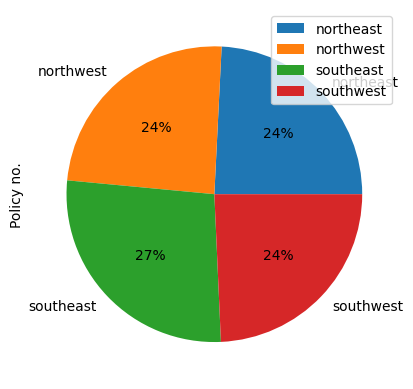

In [23]:
# Plotting the pie chart for above dataframe 
df.groupby(['region']).count().plot(kind='pie', y='Policy no.', autopct='%1.0f%%') 

Ans3. Based upon the geographic location of the person, we can see that most of the people are from the south east region followed by the other regions which have same no. of people percenatge who have insurance policies. So, i think it might or might not be necessary for the company to offer any seperate policies.

Q4. Does the no. of dependents make a difference in the amount claimed?

In [24]:
# Find the count of target variable i.e Dependents/ Children
df['children'].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

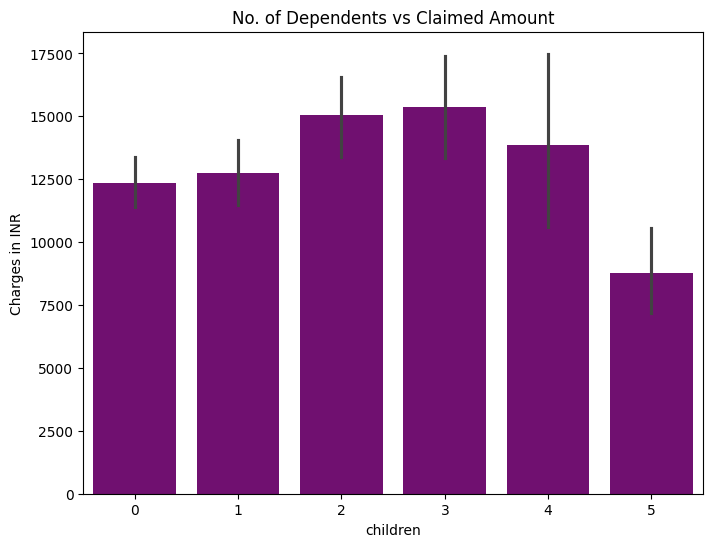

In [25]:
plt.figure(figsize=(8,6))
sns.barplot(x=df['children'],y=df['charges in INR'],color='purple')
plt.title('No. of Dependents vs Claimed Amount')
plt.xlabel('children')
plt.ylabel('Charges in INR')
plt.show()

<Axes: ylabel='charges in INR'>

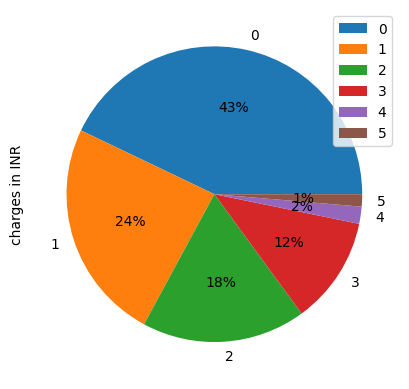

In [26]:
# Plotting the pie chart for above dataframe 
df.groupby(['children']).count().plot(kind='pie', y='charges in INR', autopct='%1.0f%%') 

Ans4. Yes, the no. of dependents can affect the claimed amount.Based upon the No. of dependents, we can see that the claimed amount can get reduced for the person having 2 or more children if it is shared among others in case of a family floater plan or they can get the full amount also if the children have their own indivual policy. In case of 1 dependent,it won't affect much.

Q5. Does a study of persons BMI get the company any idea for the insurance claim that it would extend?

In [27]:
# Define function to categorize BMI values
def bmi_categorize(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif 18.5 <= bmi <= 25:
        return "Normal Weight"
    elif 25  <= bmi <= 30:
        return "Over Weight"
    else :
        return "Obese" 

In [28]:
df['Category'] =  df['bmi'].apply(bmi_categorize)
df.head()

,Policy no.,age,sex,bmi,charges in INR,children,smoker,region,Age_Range,Avg_Amt,Category
0,PLC156898,19,female,27.900,16884.92400,0,yes,southwest,Under 20,13270.422265,Over Weight
1,PLC156907,18,male,33.770,1725.55230,1,no,southeast,Under 20,13270.422265,Obese
2,PLC156916,28,male,33.000,4449.46200,3,no,southeast,30 - 40,13270.422265,Obese
3,PLC156925,33,male,22.705,21984.47061,0,no,northwest,40 - 50,13270.422265,Normal Weight
4,PLC156934,32,male,28.880,3866.85520,0,no,northwest,40 - 50,13270.422265,Over Weight


In [29]:
df.head(20)

,Policy no.,age,sex,bmi,charges in INR,children,smoker,region,Age_Range,Avg_Amt,Category
0,PLC156898,19,female,27.900,16884.92400,0,yes,southwest,Under 20,13270.422265,Over Weight
1,PLC156907,18,male,33.770,1725.55230,1,no,southeast,Under 20,13270.422265,Obese
2,PLC156916,28,male,33.000,4449.46200,3,no,southeast,30 - 40,13270.422265,Obese
3,PLC156925,33,male,22.705,21984.47061,0,no,northwest,40 - 50,13270.422265,Normal Weight
4,PLC156934,32,male,28.880,3866.85520,0,no,northwest,40 - 50,13270.422265,Over Weight
5,PLC156943,31,female,25.740,3756.62160,0,no,southeast,40 - 50,13270.422265,Over Weight
6,PLC156952,46,female,33.440,8240.58960,1,no,southeast,50 - 60,13270.422265,Obese
7,PLC156961,37,female,27.740,7281.50560,3,no,northwest,40 - 50,13270.422265,Over Weight
8,PLC156970,37,male,29.830,6406.41070,2,no,northeast,40 - 50,13270.422265,Over Weight
9,PLC156979,60,female,25.840,28923.13692,0,no,northwest,60+,13270.422265,Over Weight


In [30]:
grp_data=df.groupby(['Category','sex']).size()
grp_data

Category       sex   
Normal Weight  female    119
               male      108
Obese          female    334
               male      371
Over Weight    female    197
               male      189
Underweight    female     12
               male        8
dtype: int64

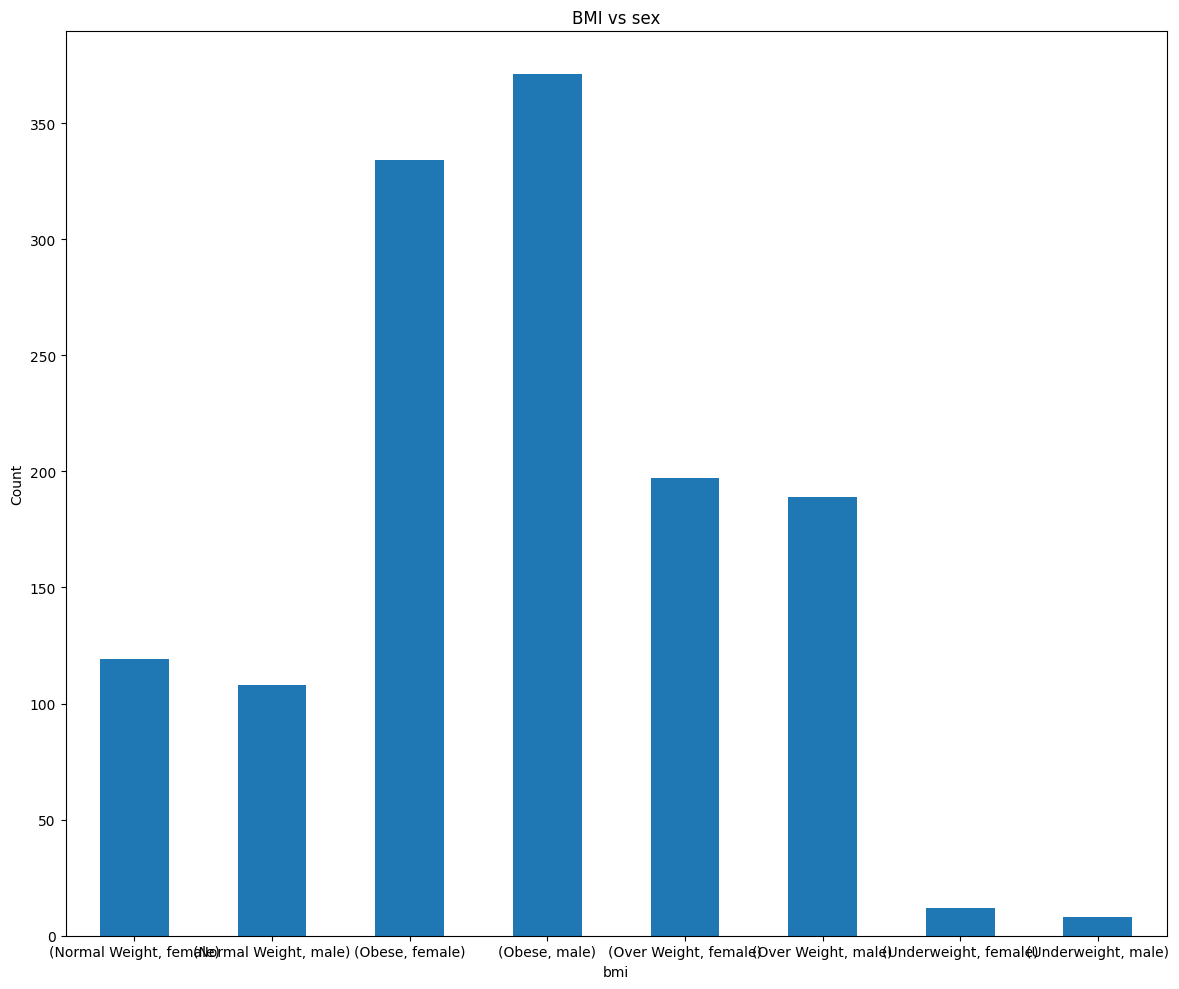

In [31]:
grp_data.plot(kind='bar', figsize=(12, 10))
plt.title('BMI vs sex')
plt.xlabel('bmi')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

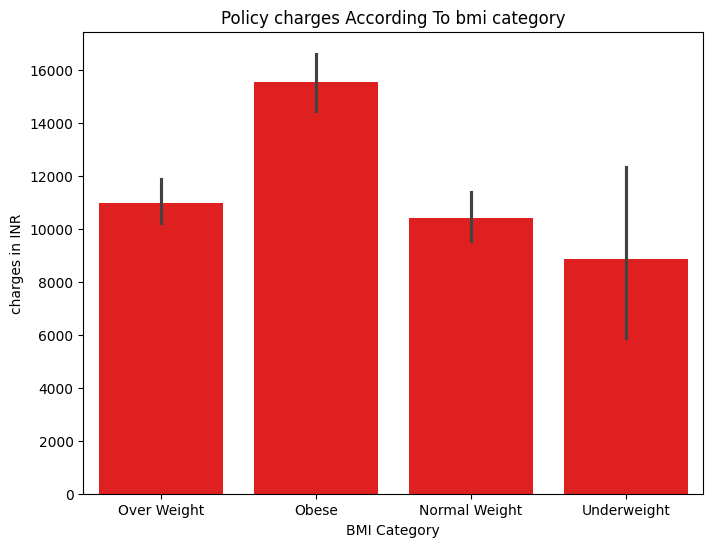

In [32]:
plt.figure(figsize=(8,6))
sns.barplot(x=df['Category'],y=df['charges in INR'],color='red')
plt.title('Policy charges According To bmi category')
plt.xlabel('BMI Category')
plt.ylabel('charges in INR')
plt.show()

Ans5. BMI plays a vvery major role in understanding whether an insurannce should be extended or not. For instance, in case of obese category, the premium would be higher due to the risk being higher.

Q6. Is it needed for the company to understand whether the person covered is a smoker or a non-smoker?

In [33]:
# Find the count of target variable i.e Smoker/No Smoker
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [34]:
gp_data=df.groupby(['smoker','sex']).size()
gp_data

smoker  sex   
no      female    547
        male      517
yes     female    115
        male      159
dtype: int64

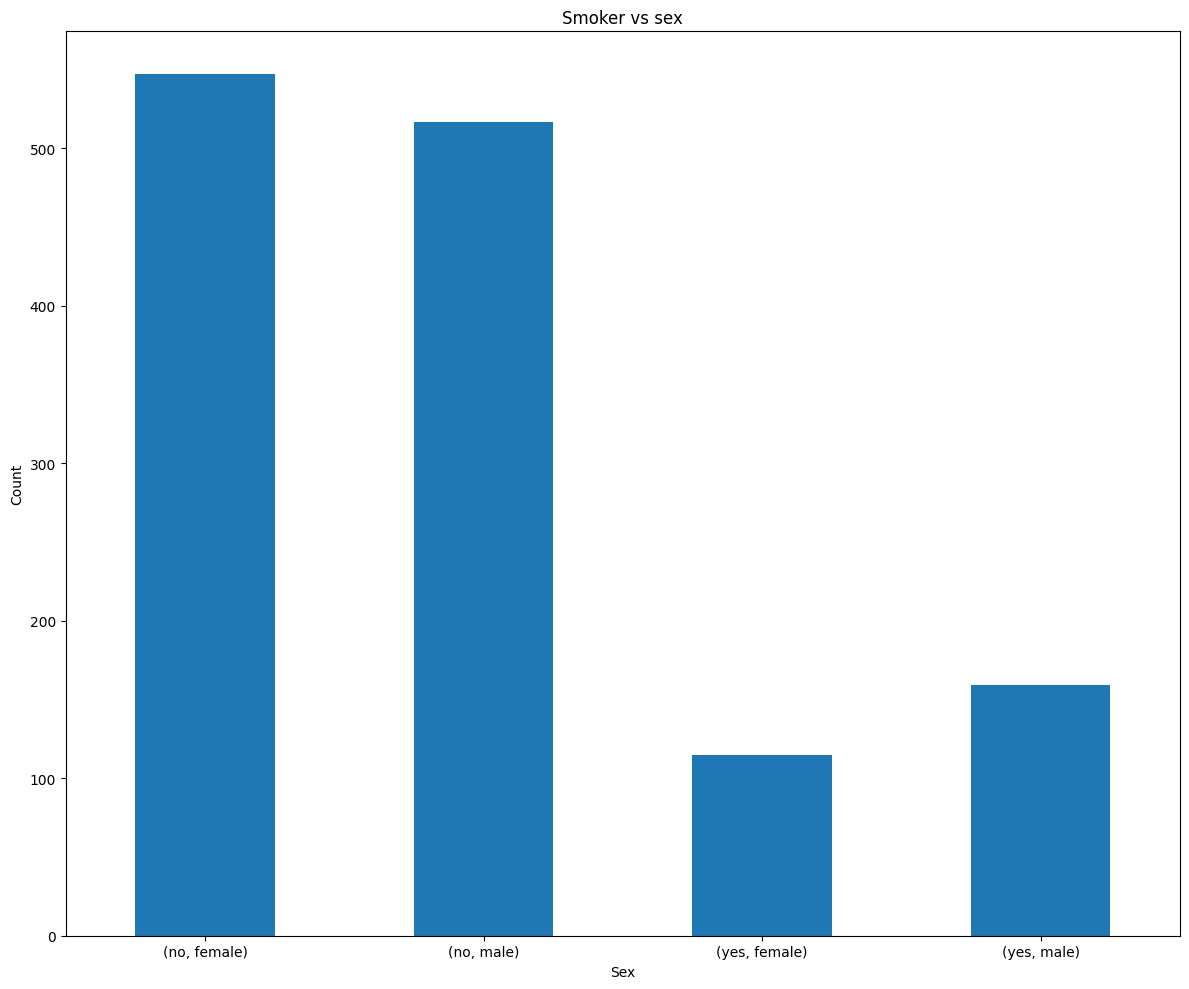

In [35]:
gp_data.plot(kind='bar', figsize=(12, 10))
plt.title('Smoker vs sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

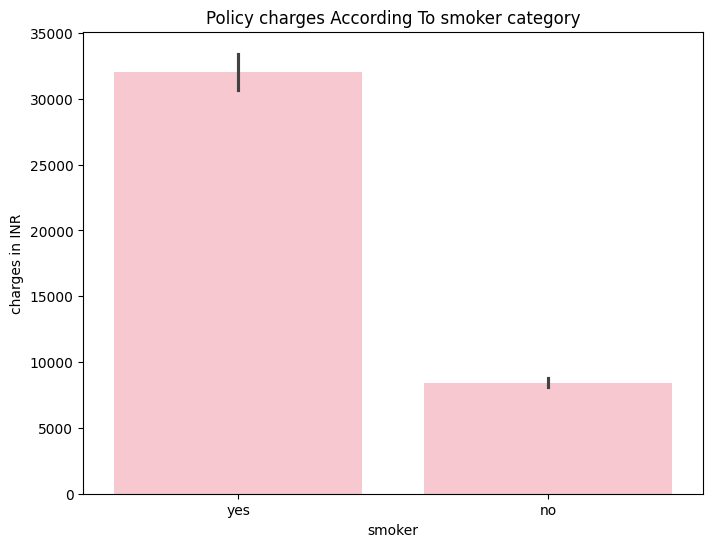

In [36]:
plt.figure(figsize=(8,6))
sns.barplot(x=df['smoker'],y=df['charges in INR'],color='pink')
plt.title('Policy charges According To smoker category')
plt.xlabel('smoker')
plt.ylabel('charges in INR')
plt.show()

Ans6. Yes, company is needed to understand whether the person covered is a smoker or a non-smoker Because smoking is considered one of the major reason in terms of health and life insurance as it is linked to higher health risks which affects premiums , coverage and ploicy approval.

Q7. Does age have any barrier on the insurance claimed?

<Axes: ylabel='charges in INR'>

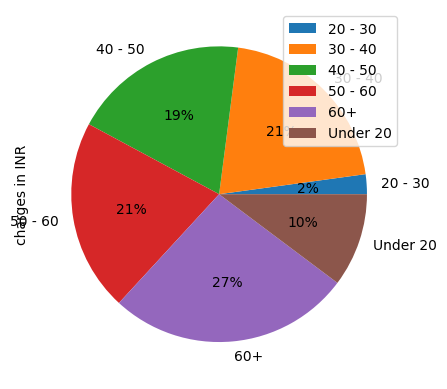

In [37]:
# Plotting the pie chart for above dataframe 
df.groupby(['Age_Range']).count().plot(kind='pie', y='charges in INR', autopct='%1.0f%%') 

<Axes: xlabel='age', ylabel='charges in INR'>

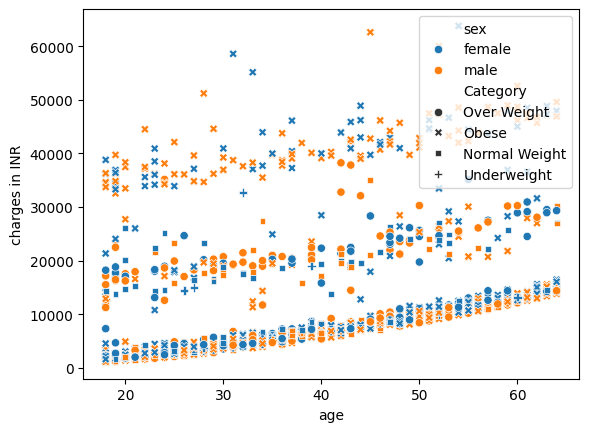

In [38]:
sns.scatterplot(data=df, x="age", y="charges in INR", hue="sex", style="Category")

<Axes: xlabel='age', ylabel='charges in INR'>

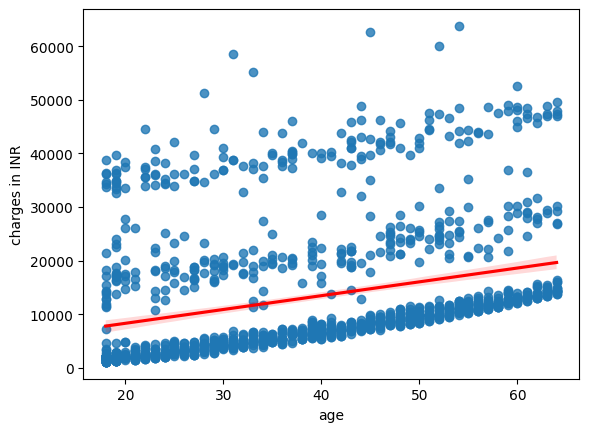

In [39]:
sns.regplot(
    data=df, x="age", y="charges in INR",line_kws=dict(color="r"),
)

Ans7. According to the above Visualization, we can say there is some kind of a positive correlation between the two values(Age & Insurance). So, I think Age causes some kind of barriers as if Age increases then the amount of claim also gets increased.

Q8. Can the company extend certain discounts after checking the health status (BMI) in this case?

In [40]:
df.head()

,Policy no.,age,sex,bmi,charges in INR,children,smoker,region,Age_Range,Avg_Amt,Category
0,PLC156898,19,female,27.900,16884.92400,0,yes,southwest,Under 20,13270.422265,Over Weight
1,PLC156907,18,male,33.770,1725.55230,1,no,southeast,Under 20,13270.422265,Obese
2,PLC156916,28,male,33.000,4449.46200,3,no,southeast,30 - 40,13270.422265,Obese
3,PLC156925,33,male,22.705,21984.47061,0,no,northwest,40 - 50,13270.422265,Normal Weight
4,PLC156934,32,male,28.880,3866.85520,0,no,northwest,40 - 50,13270.422265,Over Weight


<Figure size 1400x800 with 0 Axes>

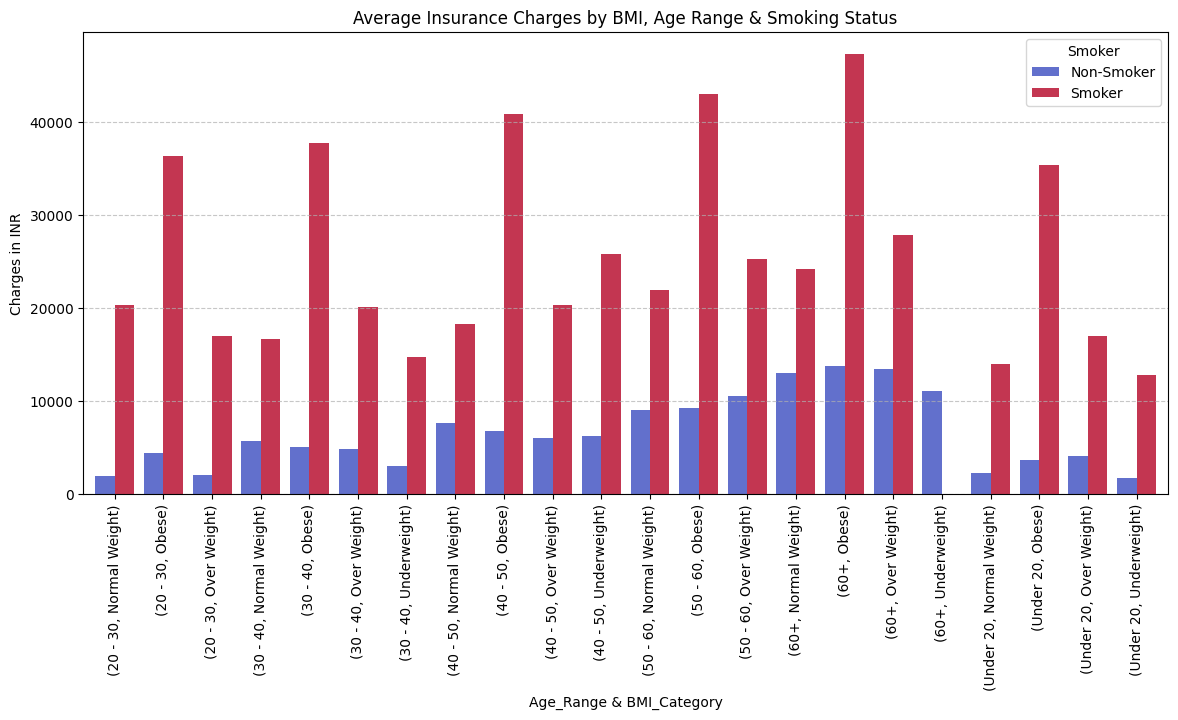

In [41]:
# Group by BMI Category, Smoking Status, and Age Group
bmi_age_smoke_analysis = df.groupby(["Age_Range", "Category", "smoker"])["charges in INR"].mean().unstack()

# Plot the results
plt.figure(figsize=(14, 8))
bmi_age_smoke_analysis.plot(kind="bar", figsize=(14, 6), colormap="coolwarm", alpha=0.8, width=0.8)
plt.title("Average Insurance Charges by BMI, Age Range & Smoking Status")
plt.ylabel("Charges in INR")
plt.xlabel("Age_Range & BMI_Category")
plt.legend(title="Smoker", labels=["Non-Smoker", "Smoker"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

Ans8. Yes,by looking at the above graph we can incur that the company can extend certain discounts after checking the health status (BMI).